# AVLLM Interpretability: Logit Lens + Attention Knockout

## Goal

Run both experiments on one chosen video with Qwen2.5-Omni-3B:

1. **Logit Lens**: decode the model's intermediate predictions at audio-token positions across thinker layers.
2. **Attention Knockout**: compare a baseline response with a response generated after blocking a chosen source-to-target attention path.

Change `VIDEO_PATH` in the parameter cell to analyze your own local video.

## tl;dr

On a clean Linux/macOS machine, run the bootstrap cells below once. They clone the upstream repository when needed, install uv if missing, create a project-local `.venv`, install the known-working runtime, and register a Jupyter kernel. Switch to that kernel and run the remaining cells top-to-bottom. The default 8-frame sample fits the tested 24 GB RTX 3090 setup; increase it cautiously because attention memory grows quickly with video-token count.


## Setup: fresh-machine bootstrap

These cells are safe to rerun. They use HTTPS so cloning does not require a GitHub SSH key. If this notebook already lives in an `avllm_interpretability` checkout, cloning is skipped.

> **Handoff note:** until this notebook is committed and pushed, copy this `.ipynb` file into the cloned repository before opening it on another machine.

**Windows:** install uv with the official PowerShell installer first, then run the remaining bootstrap logic from a Python-enabled Jupyter session. The automated uv installer below targets Linux/macOS.


### 0a. Find or clone the project

Run this unchanged. It reuses the current checkout or clones the repository with HTTPS.

In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = 'https://github.com/ramaneswaran/avllm_interpretability.git'
LAUNCH_DIRECTORY = Path.cwd().resolve()

# If Jupyter started inside a checkout, use it. Otherwise clone beside the notebook launch directory.
if (LAUNCH_DIRECTORY / 'src').is_dir() and (LAUNCH_DIRECTORY / 'requirements.txt').is_file():
    PROJECT_DIR = LAUNCH_DIRECTORY
else:
    PROJECT_DIR = LAUNCH_DIRECTORY / 'avllm_interpretability'
    if not PROJECT_DIR.exists():
        subprocess.run(['git', 'clone', REPOSITORY_URL, str(PROJECT_DIR)], check=True)

os.chdir(PROJECT_DIR)
print(f'Project directory: {PROJECT_DIR}')
print(f'Git remote: {REPOSITORY_URL}')


Project directory: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability
Git remote: git@github.com:youngjuene/CTP49906_2026.git


### 0b. Create or verify the project environment

Run this unchanged. It installs the tested CUDA and notebook packages only when the project environment is missing or incomplete.

In [2]:
# Provision a self-contained runtime. The direct package list avoids the upstream
# historical transformers==4.52.0.dev0 pin, which is no longer published.
if shutil.which('uv'):
    UV_BIN = Path(shutil.which('uv'))
else:
    candidate = Path.home() / '.local' / 'bin' / 'uv'
    if not candidate.exists():
        if os.name == 'nt':
            raise RuntimeError('Install uv with the official PowerShell installer, then rerun this cell.')
        subprocess.run(['bash', '-lc', 'curl -LsSf https://astral.sh/uv/install.sh | sh'], check=True)
    UV_BIN = candidate

VENV_DIR = PROJECT_DIR / '.venv'
PROJECT_PYTHON = VENV_DIR / ('Scripts/python.exe' if os.name == 'nt' else 'bin/python')
required_modules = ('torch', 'transformers', 'qwen_omni_utils', 'matplotlib', 'ipykernel')
needs_install = not PROJECT_PYTHON.exists()
if not needs_install:
    probe = subprocess.run(
        [str(PROJECT_PYTHON), '-c', 'import ' + ', '.join(required_modules)],
        cwd=PROJECT_DIR,
        capture_output=True,
        text=True,
    )
    needs_install = probe.returncode != 0

if needs_install:
    subprocess.run([str(UV_BIN), 'venv', '--python', '3.10', '--seed', str(VENV_DIR)], check=True, cwd=PROJECT_DIR)
    runtime_packages = [
        'openai==2.30.0',
        'qwen_omni_utils==0.0.9',
        'accelerate==1.14.0',
        'torch==2.6.0+cu124',
        'torchvision==0.21.0+cu124',
        'transformers==4.52.0',
        'jupyterlab',
        'ipykernel',
        'matplotlib',
    ]
    subprocess.run(
        [
            str(UV_BIN), 'pip', 'install', '--python', str(PROJECT_PYTHON),
            '--extra-index-url', 'https://download.pytorch.org/whl/cu124',
            *runtime_packages,
        ],
        check=True,
        cwd=PROJECT_DIR,
    )
    subprocess.run(
        [str(PROJECT_PYTHON), '-m', 'ipykernel', 'install', '--sys-prefix',
         '--name', 'avllm-interpretability', '--display-name', 'AVLLM Interpretability (.venv)'],
        check=True,
        cwd=PROJECT_DIR,
    )
else:
    print(f'Reusing existing environment: {PROJECT_PYTHON}')

subprocess.run([str(UV_BIN), 'pip', 'check', '--python', str(PROJECT_PYTHON)], check=True, cwd=PROJECT_DIR)
print(f'Project Python: {PROJECT_PYTHON}')


Reusing existing environment: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/.venv/bin/python
Project Python: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/.venv/bin/python


Checked 156 packages in 3ms
All installed packages are compatible


### Switch to the project kernel

If the bootstrap created a new environment, switch the notebook kernel to **AVLLM Interpretability (.venv)** and use **Run All**. In JupyterLab you can also reopen this notebook with:

```bash
.venv/bin/jupyter lab
```

The guard cell below intentionally stops execution if the active kernel is not the project environment, preventing accidental CPU-only or dependency-mismatched runs.


In [3]:
if Path(sys.prefix).resolve() != VENV_DIR.resolve():
    raise RuntimeError(
        'Environment provisioned. Switch to the “AVLLM Interpretability (.venv)” kernel, then run all cells again.'
    )
print(f'Active project kernel: {sys.executable}')


Active project kernel: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/.venv/bin/python


## Experiment parameters

All paths below are resolved from the cloned project directory. Keep `NFRAMES=8` on 24 GB GPUs; larger values can exhaust VRAM during attention computation.


In [4]:
# Edit these values for your own experiment.
VIDEO_PATH = PROJECT_DIR / 'assets' / '02321.mp4'
MODEL_PATH = 'Qwen/Qwen2.5-Omni-3B'
NFRAMES = 8                 # Tested on a 24 GB RTX 3090; increase only if VRAM permits.
LOGIT_PROMPT = 'Describe what you hear in the video'
ATTENTION_PROMPT = 'Describe what you see and hear in the video'
KNOCKOUT_RULES = [('generated', 'video', 0, 35)]  # Block generated tokens from attending to video tokens in layers 0–35.
MAX_NEW_TOKENS = 32  # Maximum number of tokens generated for each response.
ATTENTION_CAPTURE_LAYERS = (0, 2)  # Layers whose attention is captured for the heatmap; keep small to save VRAM.
SAVE_RAW_ATTENTION = False  # Set True only when you need the large per-step tensors.

RESULTS_DIR = PROJECT_DIR / 'notebook_results'
RESULTS_DIR.mkdir(exist_ok=True)
LOGIT_CSV_PATH = RESULTS_DIR / 'logit_lens_audio_token_analysis.csv'
ATTENTION_PKL_PATH = RESULTS_DIR / 'attention_knockout_result.pkl'

if not VIDEO_PATH.is_file():
    raise FileNotFoundError(f'Video not found: {VIDEO_PATH.resolve()}')

print(f'Video: {VIDEO_PATH.resolve()}')
print(f'Results: {RESULTS_DIR.resolve()}')


Video: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/assets/02321.mp4
Results: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results


### 1. Preview the selected video

The notebook sends both visual frames and the embedded audio to Qwen (`use_audio_in_video=True`).

In [5]:
from IPython.display import Video, display

display(Video(filename=str(VIDEO_PATH), embed=False, width=720))


### 2. Import helpers and check the runtime

In [6]:
import csv
import html
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, Markdown, display
from qwen_omni_utils import process_mm_info
from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor

from src.attention_knockout_experiment import block_attention
from src.attention_knockout_experiment import create_token_type_mapping as create_attention_token_mapping
from src.logitlens_experiment import analyze_and_save_audio_logits_to_csv
from src.logitlens_experiment import clear_logit_lens_hooks, create_token_type_mapping
from src.logitlens_experiment import register_logit_lens_hooks

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(DEVICE)}')
    free, total = torch.cuda.mem_get_info(DEVICE)
    print(f'Free VRAM: {free / 1024**3:.1f} / {total / 1024**3:.1f} GiB')
else:
    display(Markdown('> **Warning:** CUDA is unavailable. The notebook can run on CPU, but the model is likely impractically slow.'))


/mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.6.0+cu124
Device: cuda
GPU: NVIDIA GeForce RTX 3090
Free VRAM: 23.1 / 23.6 GiB


### 3. Define reusable model and input helpers

The model class ignores `device_map='auto'` in the tested Transformers build, so these helpers place the model explicitly on the chosen device. Logit Lens uses SDPA to reduce memory; Attention Knockout uses eager attention because its hooks modify attention masks.

In [7]:
def load_model_and_processor(attn_implementation: str):
    model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        torch_dtype='auto',
        attn_implementation=attn_implementation,
    )
    model = model.to(DEVICE)
    model.disable_talker()
    model.eval()
    processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_PATH)
    print(f'Loaded model on {model.device} with {attn_implementation} attention.')
    return model, processor


def prepare_video_inputs(model, processor, prompt: str, token_mapping_fn):
    conversation = [
        {
            'role': 'user',
            'content': [
                {'type': 'text', 'text': prompt},
                {'type': 'video', 'video': str(VIDEO_PATH), 'nframes': NFRAMES},
            ],
        }
    ]
    text = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
    audios, images, videos = process_mm_info(conversation, use_audio_in_video=True)
    inputs = processor(
        text=text,
        audio=audios,
        images=images,
        videos=videos,
        return_tensors='pt',
        padding=True,
        use_audio_in_video=True,
    )
    inputs = {name: value.to(model.device) for name, value in inputs.items()}
    token_types = token_mapping_fn(inputs['input_ids'], model.config.thinker_config)
    print('Token counts:', Counter(token_types))
    return inputs, token_types


## Logit Lens

### 4. Run the audio-token Logit Lens experiment

The forward pass remains multimodal: Qwen receives audio and sampled video frames together. The CSV analysis focuses on positions marked as `audio` tokens.

In [8]:
logit_model, logit_processor = load_model_and_processor('sdpa')
logit_inputs, logit_token_types = prepare_video_inputs(
    logit_model,
    logit_processor,
    LOGIT_PROMPT,
    create_token_type_mapping,
)

register_logit_lens_hooks(logit_model)
try:
    with torch.no_grad():
        _ = logit_model.thinker(**logit_inputs, output_hidden_states=True)
    analyze_and_save_audio_logits_to_csv(
        logit_model,
        logit_processor,
        logit_token_types,
        filename=str(LOGIT_CSV_PATH),
    )
finally:
    clear_logit_lens_hooks()

with torch.no_grad():
    logit_generated_ids = logit_model.generate(**logit_inputs, max_new_tokens=MAX_NEW_TOKENS)
logit_generated_text = logit_processor.batch_decode(
    logit_generated_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]
print(logit_generated_text)


Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:  33%|███▎      | 1/3 [00:00<00:00,  7.70it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 10.64it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 10.21it/s]

...

Unused or unrecognized kwargs: images, return_tensors.


Token counts: Counter({'video': 1196, 'audio': 248, 'text': 30})
✅ Registered 36 hooks for Logit Lens analysis.



🔬 Analyzing captured hidden states and saving to '/mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/logit_lens_audio_token_analysis.csv'...
LM Head is on device: cuda:0


✅ Successfully saved audio token logit lens analysis to '/mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/logit_lens_audio_token_analysis.csv'
🧹 Cleared all logit lens hooks.


system
You are a helpful assistant.
user
Describe what you hear in the video
assistant
In the video, you can hear the sound of a motorcycle engine revving up and down. The sound is clear and distinct, and it is the main focus of the audio. The motorcycle is likely being used to transport the cows, and the revving sound suggests that the engine is being revved up and down to change gears or accelerate. The sound of the motorcycle engine is loud and can be heard clearly throughout the video.


### 5. Visualize Logit Lens predictions

The charts show how many distinct decoded predictions appear across audio-token positions at each layer, and how dominant the most common prediction is. The table previews the raw layer-by-layer CSV.

**How to read it:** a high most-common-prediction share means the sampled audio-token positions have converged on the same decoded token at that layer.

Token_Position,Token_Type,Layer_0,Layer_1,Layer_2,Layer_3,Layer_4,Layer_5
621,audio,制约,vore,制约,制约,制约,制约
622,audio,ToDevice,ToDevice,ToDevice,ToDevice,驰援,mtree
623,audio,ież,ież,ież,ież,ież,ież
624,audio,睹,来不及,来不及,来不及,来不及,来不及
625,audio,睹,睹,睹,来不及,睹,睹
626,audio,=password,=password,=password,=password,=password,xca
627,audio,yen,一事,一事,Marca,Marca,Marca
628,audio,一事,一事,一事,getWindow,getWindow,"*)"""


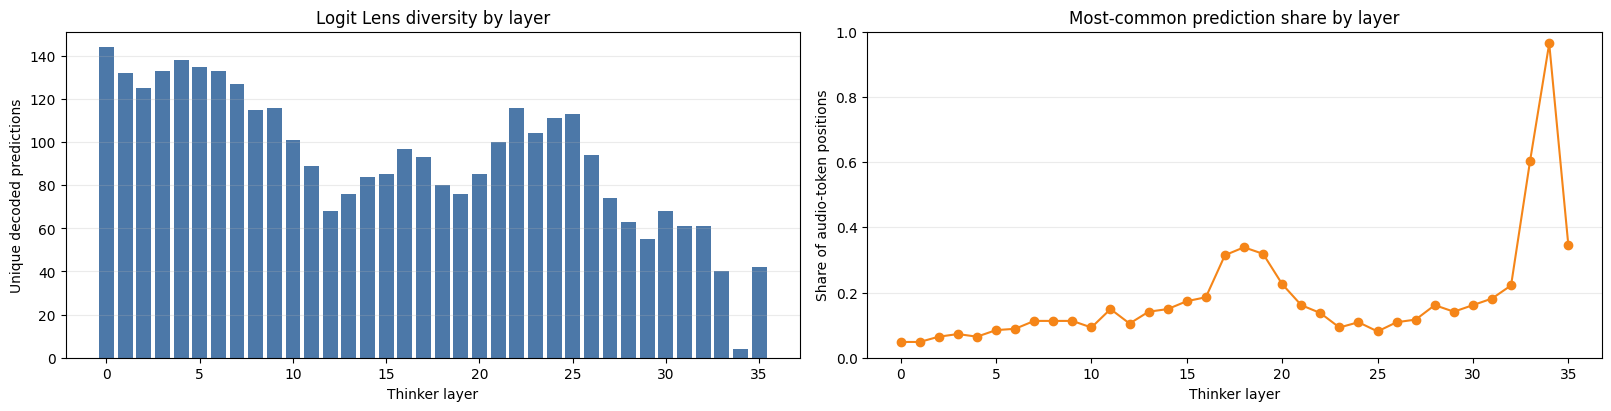

Saved raw Logit Lens rows to: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/logit_lens_audio_token_analysis.csv


In [9]:
def read_logit_lens_csv(path: Path):
    with path.open(newline='', encoding='utf-8') as handle:
        rows = list(csv.reader(handle))
    if len(rows) < 2:
        raise RuntimeError('The Logit Lens CSV contains no audio-token rows.')
    return rows[0], rows[1:]


logit_header, logit_rows = read_logit_lens_csv(LOGIT_CSV_PATH)
layer_names = logit_header[2:]
layer_predictions = list(zip(*(row[2:] for row in logit_rows)))
unique_predictions = [len(set(predictions)) for predictions in layer_predictions]
dominant_share = [Counter(predictions).most_common(1)[0][1] / len(predictions) for predictions in layer_predictions]

preview_rows = ''.join(
    '<tr>' + ''.join(f'<td>{html.escape(value)}</td>' for value in row[:8]) + '</tr>'
    for row in logit_rows[:8]
)
preview_header = ''.join(f'<th>{html.escape(value)}</th>' for value in logit_header[:8])
display(HTML(f'<table><thead><tr>{preview_header}</tr></thead><tbody>{preview_rows}</tbody></table>'))

x = np.arange(len(layer_names))
fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
axes[0].bar(x, unique_predictions, color='#4C78A8')
axes[0].set(title='Logit Lens diversity by layer', xlabel='Thinker layer', ylabel='Unique decoded predictions')
axes[1].plot(x, dominant_share, marker='o', color='#F58518')
axes[1].set(title='Most-common prediction share by layer', xlabel='Thinker layer', ylabel='Share of audio-token positions', ylim=(0, 1))
for axis in axes:
    axis.grid(axis='y', alpha=0.25)
plt.show()

print(f'Saved raw Logit Lens rows to: {LOGIT_CSV_PATH}')


### 6. Release Logit Lens memory before Attention Knockout

In [10]:
del logit_model, logit_processor, logit_inputs, logit_generated_ids
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Released Logit Lens model memory.')

Released Logit Lens model memory.


## Attention Knockout

### 7. Load the eager-attention model and prepare the same video

`KNOCKOUT_RULES` uses tuples of `(source_type, target_type, start_layer, end_layer)`. The default blocks generated tokens from attending to video tokens in layers 0–35. Valid token types are `query_text`, `audio`, `video`, `image`, and `generated`.

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Qwen2_5OmniToken2WavModel does not support eager attention implementation, fall back to sdpa


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:  33%|███▎      | 1/3 [00:00<00:00,  3.52it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  7.15it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  6.47it/s]

Loaded model on cuda:0 with eager attention.


/mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/.venv/lib/python3.10/site-packages/librosa/core/audio.py:172: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Unused or unrecognized kwargs: images, return_tensors.


Token counts: Counter({'video': 1196, 'audio': 248, 'query_text': 32})


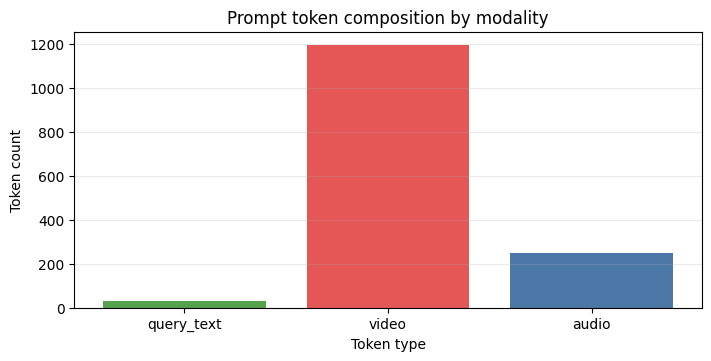

In [11]:
attention_model, attention_processor = load_model_and_processor('eager')
attention_inputs, attention_token_types = prepare_video_inputs(
    attention_model,
    attention_processor,
    ATTENTION_PROMPT,
    create_attention_token_mapping,
)

fig, axis = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
counts = Counter(attention_token_types)
axis.bar(counts.keys(), counts.values(), color=['#54A24B', '#E45756', '#4C78A8', '#B279A2'])
axis.set(title='Prompt token composition by modality', xlabel='Token type', ylabel='Token count')
axis.grid(axis='y', alpha=0.25)
plt.show()


### 8. Generate a baseline and a knockout response

The baseline uses the same prompt and video without hooks. The second run applies the selected rules and captures a small range of attention layers for visualization.

In [12]:
def decode_generation(processor, generation_output):
    return processor.batch_decode(
        generation_output.sequences,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]


with torch.no_grad():
    baseline_output = attention_model.generate(
        **attention_inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        return_dict_in_generate=True,
    )
baseline_text = decode_generation(attention_processor, baseline_output)

with block_attention(
    attention_model,
    KNOCKOUT_RULES,
    attention_token_types,
    len(attention_token_types),
    track_attention=True,
    capture_layer_range=ATTENTION_CAPTURE_LAYERS,
) as captured_attention:
    with torch.no_grad():
        knockout_output = attention_model.generate(
            **attention_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            output_attentions=True,
            return_dict_in_generate=True,
        )
    captured_attention = {layer: list(values) for layer, values in captured_attention.items()}

knockout_text = decode_generation(attention_processor, knockout_output)
comparison_html = f'''<table style="width:100%">
<thead><tr><th>Baseline</th><th>Knockout: {html.escape(str(KNOCKOUT_RULES))}</th></tr></thead>
<tbody><tr><td><pre style="white-space:pre-wrap">{html.escape(baseline_text)}</pre></td>
<td><pre style="white-space:pre-wrap">{html.escape(knockout_text)}</pre></td></tr></tbody></table>'''
display(HTML(comparison_html))


Applying ATTENTION CAPTURE to layer range: [0, 2)
Applied 35 total knockout hooks across layers.
Rule configuration: [('generated', 'video', 0, 35)]
Applied 2 attention capture hooks.


Removed 35 knockout hooks.
Removed 2 capture hooks.


Baseline,"Knockout: [('generated', 'video', 0, 35)]"
"system You are a helpful assistant. user Describe what you see and hear in the video assistant The video shows a herd of cows grazing in a lush green field with mountains in the background. A man is seen walking among the cows, possibly tending to them. The cows are of various colors, including brown and white, and they are scattered throughout the field. The man is wearing a green shirt and appears to be focused on his work. The cows are calm and seem to be enjoying their time in the field. The video captures the peacefulness of rural life and the beauty of nature.","system You are a helpful assistant. user Describe what you see and hear in the video assistant The video shows a person riding a bicycle on a road. The person is wearing a helmet and appears to be pedaling at a steady pace. The background is a mix of trees and buildings, indicating that the person is likely in an urban or suburban area. The sound of the bicycle wheels turning and the person's breathing can be heard throughout the video."


### 9. Visualize captured attention by key modality

**Advanced implementation:** run the next cell unchanged unless you are modifying the visualization. For every captured layer and generation snapshot, the notebook averages heads, then sums the final query's attention mass over the original audio, video, and text token groups. If the installed model does not expose attention tensors, the response comparison and token-composition chart remain valid and this cell explains the gap.

**How to read it:** this is a descriptive attention summary, not causal importance by itself. Use the baseline-versus-knockout text comparison above to judge the intervention effect.

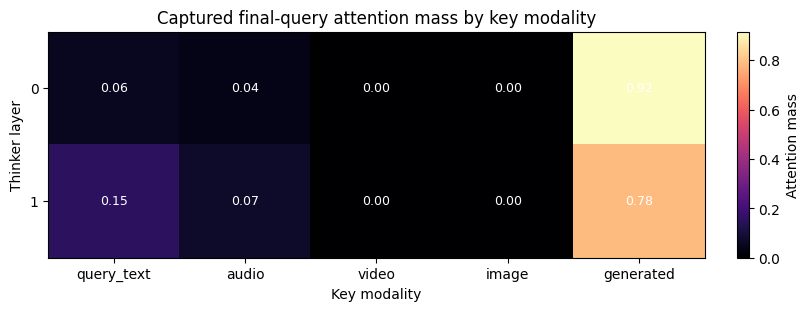

In [13]:
def summarize_attention_by_modality(storage, prompt_token_types):
    modality_order = ['query_text', 'audio', 'video', 'image', 'generated']
    records = []
    prompt_length = len(prompt_token_types)

    for layer, snapshots in sorted(storage.items()):
        for snapshot in snapshots:
            tensor = snapshot.detach().float().cpu()
            if tensor.ndim == 4:  # [batch, heads, query, key]
                mean_attention = tensor[0].mean(dim=0)
            elif tensor.ndim == 3:  # [heads, query, key]
                mean_attention = tensor.mean(dim=0)
            else:
                continue

            key_attention = mean_attention[-1] if mean_attention.shape[0] else mean_attention
            key_types = prompt_token_types + ['generated'] * max(0, key_attention.shape[-1] - prompt_length)
            for modality in modality_order:
                indices = [idx for idx, token_type in enumerate(key_types) if token_type == modality]
                if indices:
                    records.append((layer, modality, float(key_attention[indices].sum())))

    if not records:
        return None

    layers = sorted({layer for layer, _, _ in records})
    matrix = np.zeros((len(layers), len(modality_order)), dtype=float)
    for row_idx, layer in enumerate(layers):
        for column_idx, modality in enumerate(modality_order):
            values = [value for rec_layer, rec_modality, value in records if rec_layer == layer and rec_modality == modality]
            matrix[row_idx, column_idx] = np.mean(values) if values else 0.0
    return layers, modality_order, matrix


summary = summarize_attention_by_modality(captured_attention, attention_token_types)
if summary is None:
    display(Markdown('> No attention tensors were returned by this model configuration. The baseline/knockout text comparison above is still the experiment result.'))
else:
    layers, modalities, attention_matrix = summary
    fig, axis = plt.subplots(figsize=(8, max(3, len(layers) * 0.6)), constrained_layout=True)
    image = axis.imshow(attention_matrix, aspect='auto', cmap='magma')
    axis.set(
        title='Captured final-query attention mass by key modality',
        xlabel='Key modality',
        ylabel='Thinker layer',
        xticks=np.arange(len(modalities)),
        xticklabels=modalities,
        yticks=np.arange(len(layers)),
        yticklabels=layers,
    )
    for row_idx in range(attention_matrix.shape[0]):
        for column_idx in range(attention_matrix.shape[1]):
            axis.text(column_idx, row_idx, f'{attention_matrix[row_idx, column_idx]:.2f}', ha='center', va='center', color='white', fontsize=9)
    fig.colorbar(image, ax=axis, label='Attention mass')
    plt.show()


### 10. Save the Attention Knockout result

In [14]:
attention_summary_payload = None
if summary is not None:
    layers, modalities, attention_matrix = summary
    attention_summary_payload = {
        'layers': layers,
        'modalities': modalities,
        'attention_mass': attention_matrix.tolist(),
    }

attention_payload = {
    'video_path': str(VIDEO_PATH.resolve()),
    'model_path': MODEL_PATH,
    'nframes': NFRAMES,
    'prompt': ATTENTION_PROMPT,
    'knockout_rules': KNOCKOUT_RULES,
    'capture_layer_range': ATTENTION_CAPTURE_LAYERS,
    'token_mapping': attention_token_types,
    'baseline_text': baseline_text,
    'knockout_text': knockout_text,
    'attention_summary': attention_summary_payload,
    'captured_attention_shapes': {
        layer: [list(tensor.shape) for tensor in tensors]
        for layer, tensors in captured_attention.items()
    },
    'raw_attention_saved': SAVE_RAW_ATTENTION,
}
if SAVE_RAW_ATTENTION:
    attention_payload['attention_weights_per_step'] = captured_attention

with ATTENTION_PKL_PATH.open('wb') as handle:
    pickle.dump(attention_payload, handle)

print(f'Saved Attention Knockout result to: {ATTENTION_PKL_PATH}')
print(f'Raw attention tensors saved: {SAVE_RAW_ATTENTION}')


Saved Attention Knockout result to: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/attention_knockout_result.pkl
Raw attention tensors saved: False


## Checks

- Confirm the Logit Lens CSV exists and contains audio-token rows.
- Confirm the Attention Knockout pickle exists and contains the chosen rule plus generated text.
- For a different video, change only `VIDEO_PATH` and optionally `NFRAMES`, then rerun from the parameter cell.


In [15]:
assert LOGIT_CSV_PATH.is_file() and LOGIT_CSV_PATH.stat().st_size > 0
assert ATTENTION_PKL_PATH.is_file() and ATTENTION_PKL_PATH.stat().st_size > 0
print('✓ Logit Lens CSV:', LOGIT_CSV_PATH)
print('✓ Attention Knockout result:', ATTENTION_PKL_PATH)


✓ Logit Lens CSV: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/logit_lens_audio_token_analysis.csv
✓ Attention Knockout result: /mnt/hdd/research/2026/CTP49906_2026/avllm_interpretability/notebook_results/attention_knockout_result.pkl


## Next Steps

- Change `KNOCKOUT_RULES` to test audio-to-video, generated-to-audio, or other valid source/target pairs.
- Increase `ATTENTION_CAPTURE_LAYERS` only if you need deeper attention inspection and have memory headroom.
- Use the two saved result files as inputs to downstream statistical comparisons across multiple videos.
